(976, 11)
Make                 object
Make_Year             int64
Color                object
Body_Type            object
Mileage_Run           int64
No_of_Owners         object
Seating_Capacity      int64
Fuel_Type            object
Transmission         object
Transmission_Type    object
Price                 int64
dtype: object
Make                 0
Make_Year            0
Color                0
Body_Type            0
Mileage_Run          0
No_of_Owners         0
Seating_Capacity     0
Fuel_Type            0
Transmission         0
Transmission_Type    0
Price                0
dtype: int64
         Make_Year   Mileage_Run  Seating_Capacity         Price
count   976.000000    976.000000        976.000000  9.760000e+02
mean   2016.963115  41571.195697          5.095287  7.410195e+05
std       2.818742  24390.995134          0.446224  3.673234e+05
min    2011.000000   1117.000000          4.000000  1.880000e+05
25%    2015.000000  22676.750000          5.000000  4.757500e+05
50%    2017.

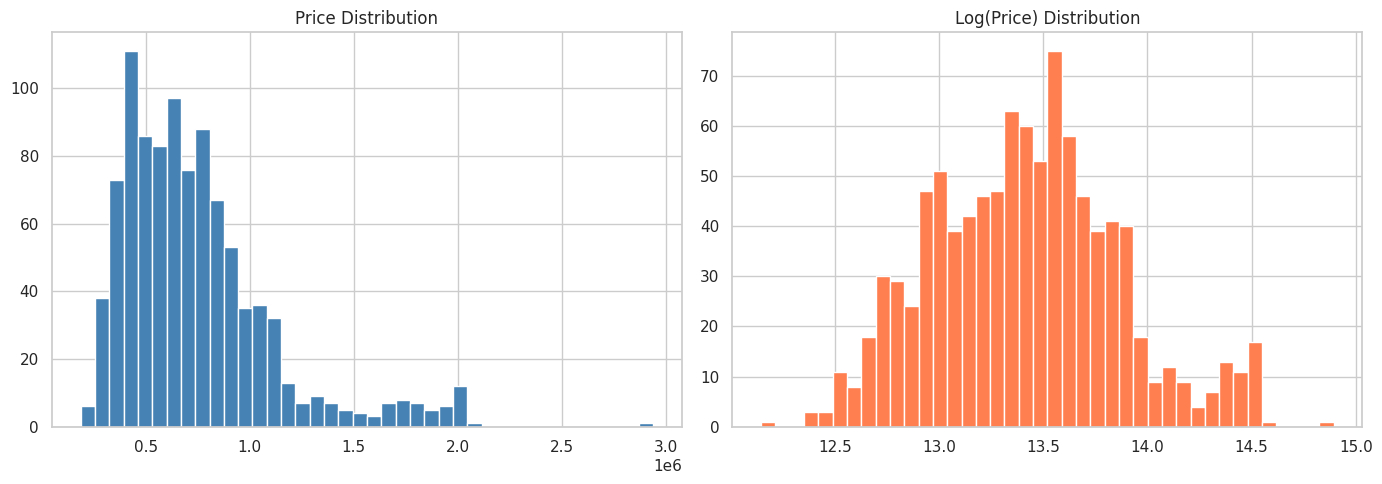

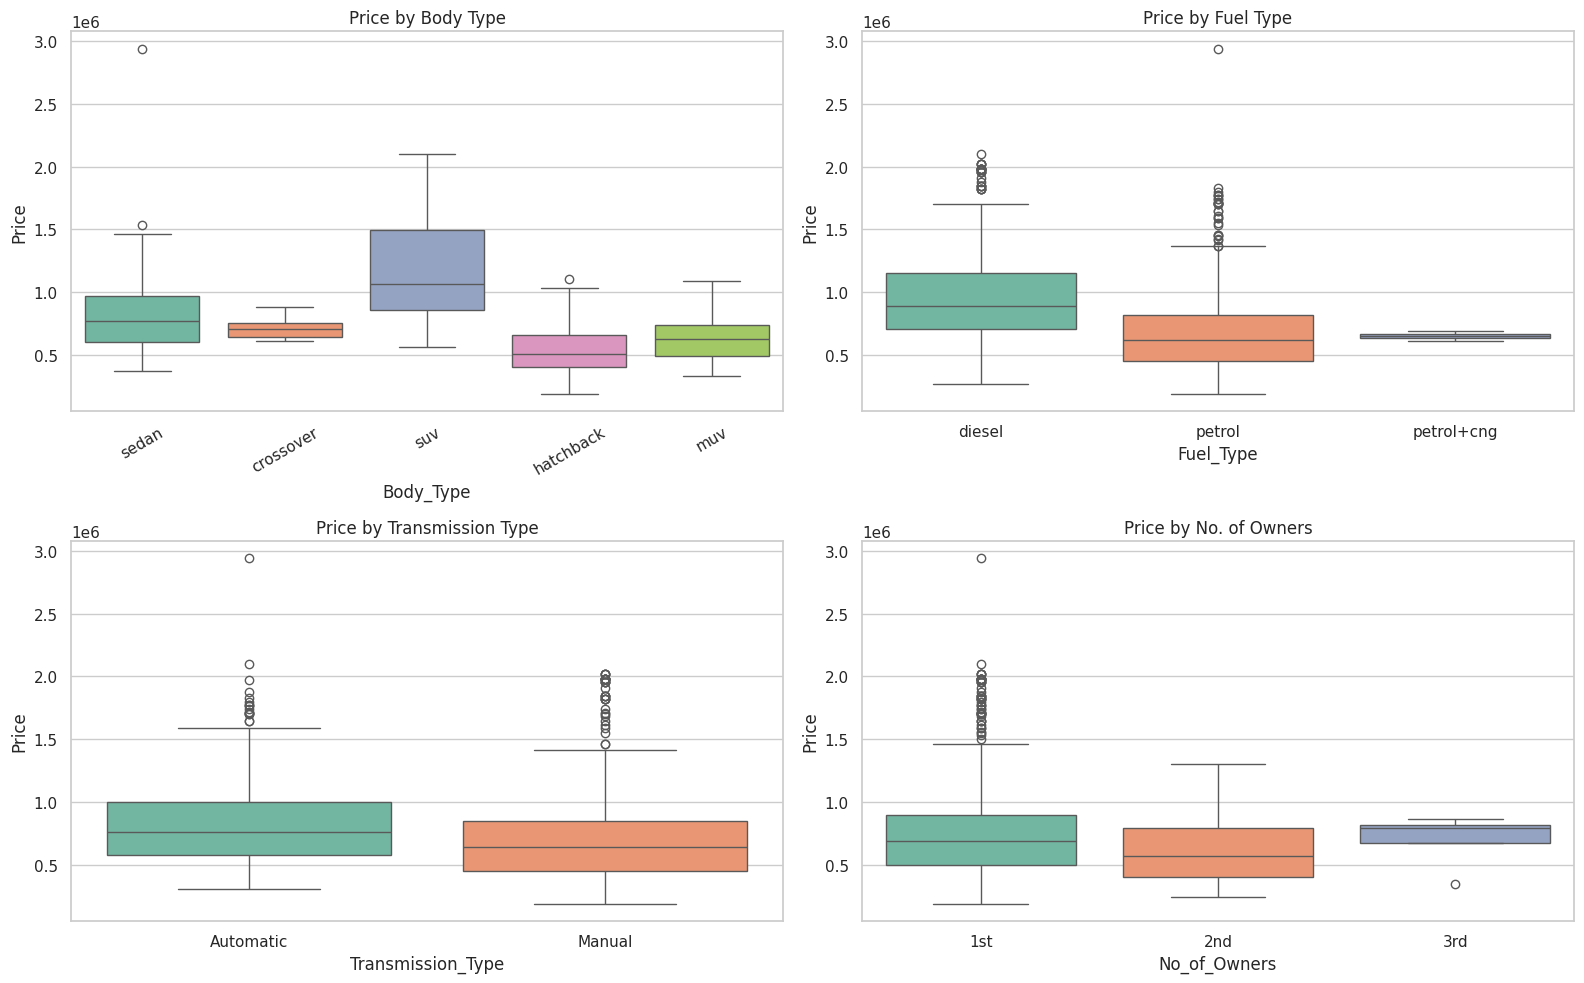

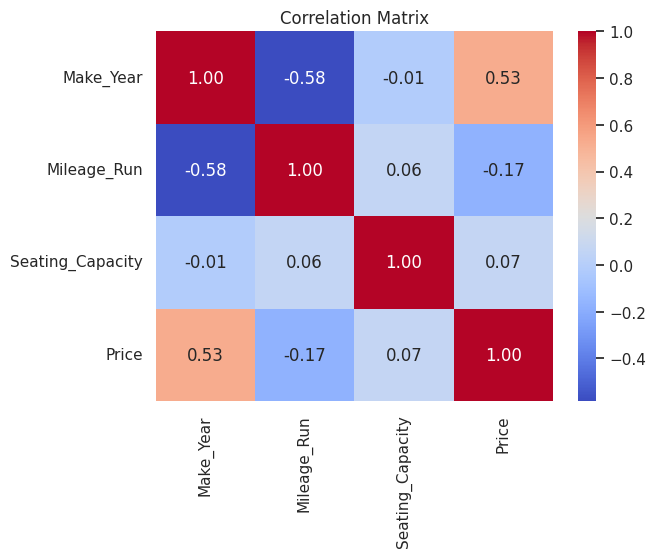

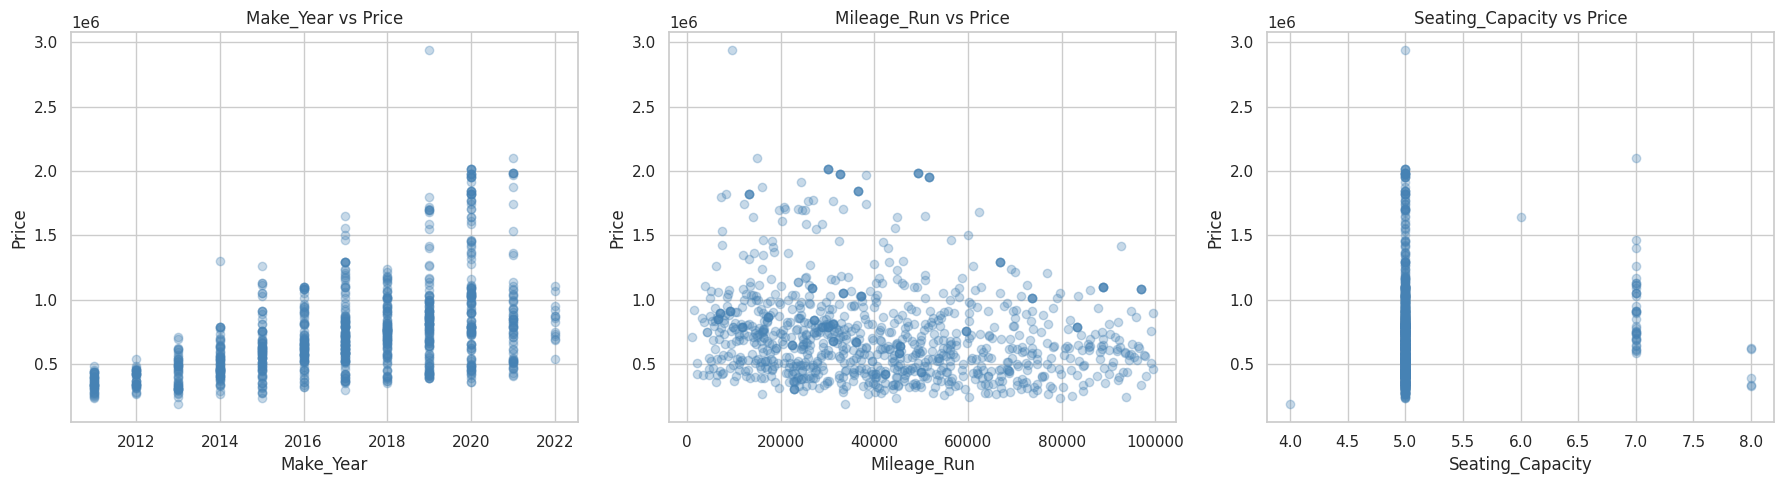

Shape after encoding: (976, 41)
Train: (780, 40) | Test: (196, 40)
Model 1: Numeric Only | Train: RMSE=306,478  R2=0.3271
Model 1: Numeric Only | Test: RMSE=279,970  R2=0.3166
Model 2: + Body & Fuel | Train: RMSE=221,074  R2=0.6499
Model 2: + Body & Fuel | Test: RMSE=205,329  R2=0.6324
Model 3: All Features | Train: RMSE=148,719  R2=0.8415
Model 3: All Features | Test: RMSE=155,703  R2=0.7886


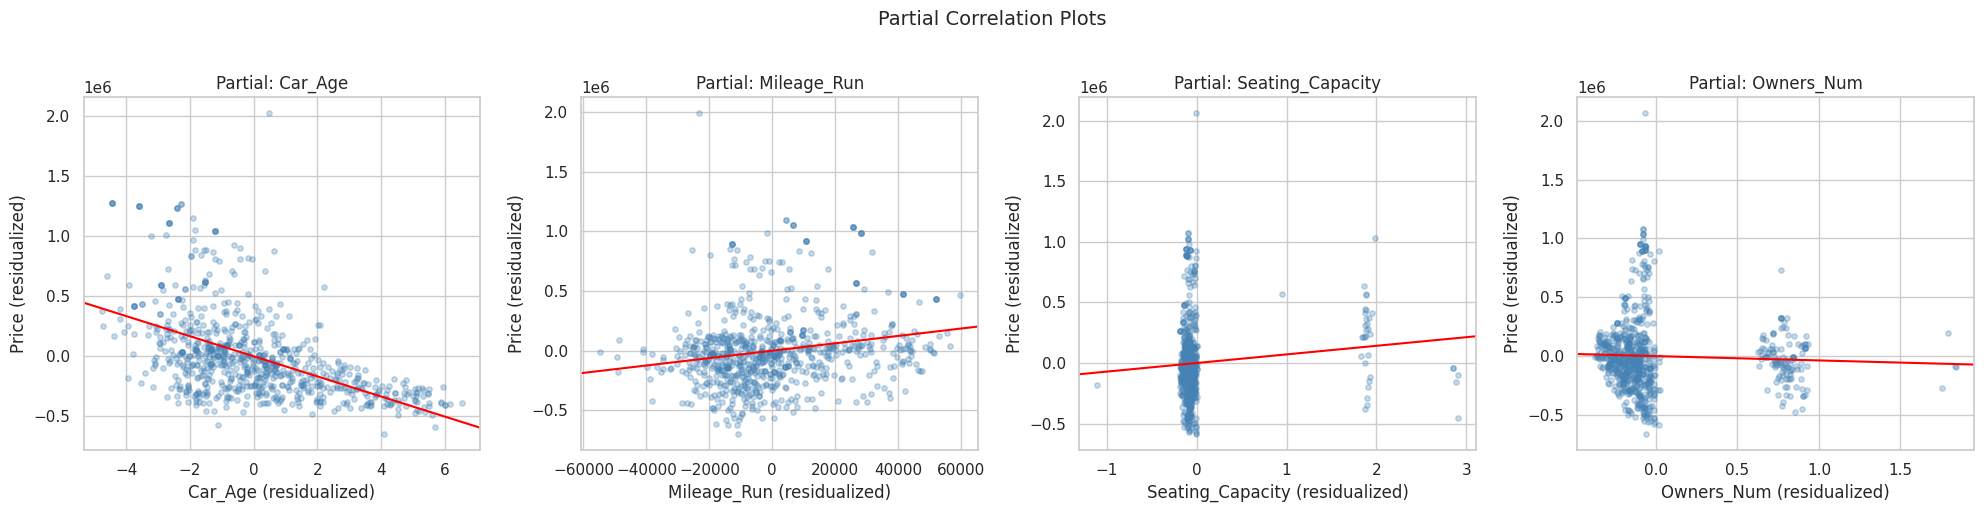

Model 4: Complex | Train: RMSE=146,171  R2=0.8469
Model 4: Complex | Test: RMSE=152,141  R2=0.7982
Model 5: log(Price) | Train: RMSE=143,333  R2=0.8528
Model 5: log(Price) | Test: RMSE=138,107  R2=0.8337

     Alpha    Train R2     Test R2     Test RMSE    Non-zero
       100      0.8468      0.7976       152,368          44
      1000      0.8430      0.7973       152,458          40
      5000      0.8313      0.7790       159,198          30
     10000      0.8191      0.7652       164,091          21
     50000      0.6952      0.6546       199,038           6
    100000      0.5669      0.5252       233,364           4

Lasso selected 30 features:
             Feature    Coefficient
      Make_MG Motors  127918.688095
             Car_Age -124366.024909
       Body_Type_suv   82538.400497
 Body_Type_hatchback  -67882.991414
    Fuel_Type_petrol  -58080.257140
        Make_Renault  -48426.324685
            Make_Kia   45886.794763
          Make_Skoda   38197.434796
           Make

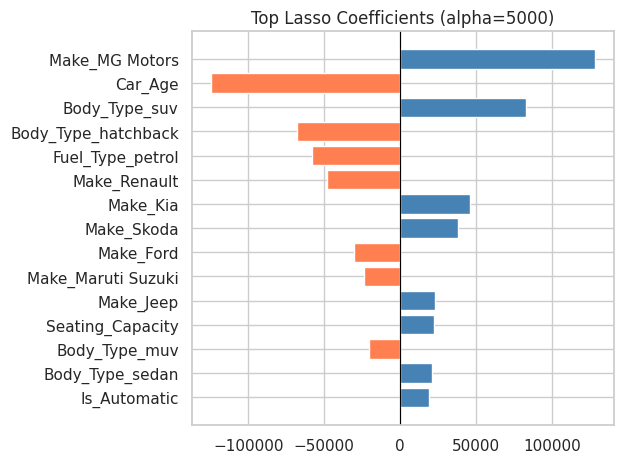

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')

# ── 1. LOAD & EDA ──────────────────────────────────────────────────────────────
df = pd.read_csv('/content/cars_hw.csv', index_col=0)
print(df.shape)
print(df.dtypes)
print(df.isnull().sum())
print(df.describe())

cat_cols = ['Make', 'Color', 'Body_Type', 'No_of_Owners', 'Fuel_Type', 'Transmission', 'Transmission_Type']
for col in cat_cols:
    print(f'\n{col}:\n', df[col].value_counts())

# Price distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df['Price'], bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Price Distribution')
axes[1].hist(np.log(df['Price']), bins=40, color='coral', edgecolor='white')
axes[1].set_title('Log(Price) Distribution')
plt.tight_layout(); plt.show()

# Price by categoricals
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
sns.boxplot(data=df, x='Body_Type', y='Price', ax=axes[0,0], palette='Set2')
axes[0,0].set_title('Price by Body Type'); axes[0,0].tick_params(axis='x', rotation=30)
sns.boxplot(data=df, x='Fuel_Type', y='Price', ax=axes[0,1], palette='Set2')
axes[0,1].set_title('Price by Fuel Type')
sns.boxplot(data=df, x='Transmission_Type', y='Price', ax=axes[1,0], palette='Set2')
axes[1,0].set_title('Price by Transmission Type')
sns.boxplot(data=df, x='No_of_Owners', y='Price', ax=axes[1,1], palette='Set2')
axes[1,1].set_title('Price by No. of Owners')
plt.tight_layout(); plt.show()

# Correlation heatmap
sns.heatmap(df[['Make_Year','Mileage_Run','Seating_Capacity','Price']].corr(),
            annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix'); plt.show()

# Scatter: numerics vs Price
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, ['Make_Year', 'Mileage_Run', 'Seating_Capacity']):
    ax.scatter(df[col], df['Price'], alpha=0.3, color='steelblue')
    ax.set_xlabel(col); ax.set_ylabel('Price'); ax.set_title(f'{col} vs Price')
plt.tight_layout(); plt.show()

# ── 2. FEATURE ENGINEERING ────────────────────────────────────────────────────
df2 = df.dropna().copy()

owner_map = {'1st': 1, '2nd': 2, '3rd': 3, '4th': 4}
df2['Owners_Num']  = df2['No_of_Owners'].map(owner_map)
df2['Is_Automatic'] = (df2['Transmission_Type'] == 'Automatic').astype(int)
df2['Car_Age']      = 2024 - df2['Make_Year']
df2 = df2.drop(columns=['Transmission', 'No_of_Owners', 'Make_Year', 'Transmission_Type'])
df2 = pd.get_dummies(df2, columns=['Make', 'Color', 'Body_Type', 'Fuel_Type'], drop_first=True)
print('Shape after encoding:', df2.shape)

# ── 3. TRAIN-TEST SPLIT ───────────────────────────────────────────────────────
X = df2.drop(columns=['Price'])
y = df2['Price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print('Train:', X_train.shape, '| Test:', X_test.shape)

# ── 4. SIMPLE LINEAR MODELS ───────────────────────────────────────────────────
def evaluate_model(model, X_tr, X_te, y_tr, y_te, name):
    model.fit(X_tr, y_tr)
    for label, X_, y_ in [('Train', X_tr, y_tr), ('Test', X_te, y_te)]:
        preds = model.predict(X_)
        rmse  = np.sqrt(mean_squared_error(y_, preds))
        r2    = r2_score(y_, preds)
        print(f'{name} | {label}: RMSE={rmse:,.0f}  R2={r2:.4f}')
    return model

num_feats  = ['Car_Age', 'Mileage_Run', 'Seating_Capacity', 'Owners_Num', 'Is_Automatic']
body_feats = [c for c in X_train.columns if c.startswith('Body_Type')]
fuel_feats = [c for c in X_train.columns if c.startswith('Fuel_Type')]

m1 = evaluate_model(LinearRegression(), X_train[num_feats], X_test[num_feats], y_train, y_test, 'Model 1: Numeric Only')
m2 = evaluate_model(LinearRegression(), X_train[num_feats+body_feats+fuel_feats], X_test[num_feats+body_feats+fuel_feats], y_train, y_test, 'Model 2: + Body & Fuel')
m3 = evaluate_model(LinearRegression(), X_train, X_test, y_train, y_test, 'Model 3: All Features')

# ── 5. PARTIAL CORRELATION PLOTS ─────────────────────────────────────────────
def partial_corr_plot(X_tr, y_tr, focus_col, all_cols, ax):
    controls = [c for c in all_cols if c != focus_col]
    x_resid  = X_tr[focus_col].values - LinearRegression().fit(X_tr[controls], X_tr[focus_col]).predict(X_tr[controls])
    y_resid  = y_tr.values            - LinearRegression().fit(X_tr[controls], y_tr).predict(X_tr[controls])
    ax.scatter(x_resid, y_resid, alpha=0.3, s=15, color='steelblue')
    m, b = np.polyfit(x_resid, y_resid, 1)
    ax.axline((0, b), slope=m, color='red', linewidth=1.5)
    ax.set_xlabel(f'{focus_col} (residualized)'); ax.set_ylabel('Price (residualized)')
    ax.set_title(f'Partial: {focus_col}')

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, col in zip(axes, ['Car_Age', 'Mileage_Run', 'Seating_Capacity', 'Owners_Num']):
    partial_corr_plot(X_train[num_feats], y_train, col, num_feats, ax)
plt.suptitle('Partial Correlation Plots', fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

# ── 6. COMPLEX MODEL ──────────────────────────────────────────────────────────
X_train_c = X_train.copy()
X_test_c  = X_test.copy()

for df_ in [X_train_c, X_test_c]:
    df_['log_Mileage']   = np.log1p(df_['Mileage_Run'])
    df_['Car_Age_sq']    = df_['Car_Age'] ** 2
    df_['Age_x_Mileage'] = df_['Car_Age'] * df_['Mileage_Run']
    df_['Auto_x_Age']    = df_['Is_Automatic'] * df_['Car_Age']

m4 = evaluate_model(LinearRegression(), X_train_c, X_test_c, y_train, y_test, 'Model 4: Complex')

# Model 5: log(Price) target
m5 = LinearRegression().fit(X_train_c, np.log(y_train))
for label, X_, y_ in [('Train', X_train_c, y_train), ('Test', X_test_c, y_test)]:
    preds = np.exp(m5.predict(X_))
    print(f'Model 5: log(Price) | {label}: RMSE={np.sqrt(mean_squared_error(y_, preds)):,.0f}  R2={r2_score(y_, preds):.4f}')

# ── 8. LASSO ──────────────────────────────────────────────────────────────────
scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train_c)
X_test_s  = scaler.transform(X_test_c)

print(f"\n{'Alpha':>10}  {'Train R2':>10}  {'Test R2':>10}  {'Test RMSE':>12}  {'Non-zero':>10}")
for a in [100, 1000, 5000, 10000, 50000, 100000]:
    lasso = Lasso(alpha=a, max_iter=10000).fit(X_train_s, y_train)
    tr_r2   = r2_score(y_train, lasso.predict(X_train_s))
    te_r2   = r2_score(y_test,  lasso.predict(X_test_s))
    te_rmse = np.sqrt(mean_squared_error(y_test, lasso.predict(X_test_s)))
    nz      = np.sum(lasso.coef_ != 0)
    print(f'{a:>10}  {tr_r2:>10.4f}  {te_r2:>10.4f}  {te_rmse:>12,.0f}  {nz:>10}')

# Best alpha — adjust after reviewing table above
best_alpha = 5000
lasso_best = Lasso(alpha=best_alpha, max_iter=10000).fit(X_train_s, y_train)
coef_df = pd.DataFrame({'Feature': X_train_c.columns, 'Coefficient': lasso_best.coef_})
coef_df = coef_df[coef_df['Coefficient'] != 0].sort_values('Coefficient', key=abs, ascending=False)
print(f'\nLasso selected {len(coef_df)} features:')
print(coef_df.to_string(index=False))

# Plot top coefficients
top = coef_df.head(15)
colors = ['steelblue' if c > 0 else 'coral' for c in top['Coefficient']]
plt.barh(top['Feature'], top['Coefficient'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title(f'Top Lasso Coefficients (alpha={best_alpha})')
plt.gca().invert_yaxis()
plt.tight_layout(); plt.show()